In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from waymo_agent import *

In [3]:
from waymo_agent.osmnx.inspect import *
from waymo_agent.osmnx.osmnx_constants import *
from waymo_agent.osmnx.sparsify import *
from waymo_agent.osmnx.utils import _max_speed_int
from waymo_agent.osmnx.post_process_enrichment import *

#### Load Sparse Graph

In [4]:
config = EnvConfig()
config.map_name

'manhattan-sparse-772-nodes-enriched.graphml'

In [5]:
G = ox.load_graphml(filepath=MAP_DIR / config.map_name)
post_load(G)

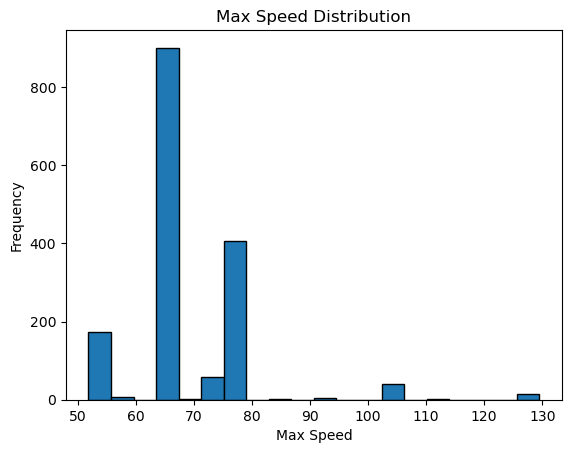

In [6]:
plot_maxspeed(G)

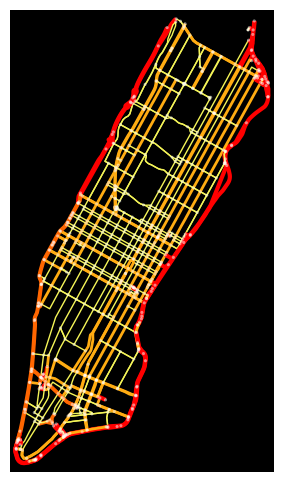

In [7]:
edge_colors, edge_widths = OSMNXConstants.get_edge_colors(G)
fig, ax = ox.plot_graph(
    G,
    edge_color=edge_colors,
    edge_linewidth=edge_widths,
    **{**OX_PLOT_DEFAULTS | {"figsize": (6, 6)}},
)

In [8]:
OX_PLOT_DEFAULTS

{'node_size': 5,
 'node_color': 'white',
 'node_alpha': 0.5,
 'figsize': (10, 10),
 'bgcolor': 'black',
 'show': True}

## Enrich Graph

In [9]:
enrich_graph(G)

Assigned 38 charging nodes.
Assigned lambda values to nodes. Total lambda: 8.8337 (target: 7.7200)


In [10]:
inspect_graph(G)

Graph has 772 nodes and 1609 edges.
Sample node attributes: {'y': 40.7653085, 'x': -73.9638433, 'highway': 'traffic_signals', 'street_count': 4, 'num_chargers': False, 'lambda': 0.0}

Sample edge attributes: {'osmid': 196117084, 'highway': 'primary', 'maxspeed': 64.74938089, 'name': 'West 57th Street', 'oneway': False, 'reversed': False, 'length': 274.30433091994433, 'lanes': '4', 'geometry': <LINESTRING (-73.983 40.767, -73.983 40.767, -73.984 40.767, -73.984 40.767,...>, 'unit': 'kph'}


In [11]:
sum_lambda = sum_graph_attr(G, "lambda", "node")
round(sum_lambda, 2)

8.83

In [12]:
sum_chargers = sum_graph_attr(G, "num_chargers", "node")
round(sum_chargers, 2)

38.0

In [13]:
from waymo_agent.osmnx.visualization_utils import *

In [14]:
OX_PLOT_DEFAULTS

{'node_size': 5,
 'node_color': 'white',
 'node_alpha': 0.5,
 'figsize': (10, 10),
 'bgcolor': 'black',
 'show': True}

In [ ]:
edge_colors, edge_widths = get_edge_color_by_speed(G)
node_colors, node_sizes = get_node_colors_and_sizes(G)

In [32]:
type(edge_colors), type(edge_colors[0]), type(edge_colors[0][0])

(list, list, float)

In [33]:
type(edge_widths), type(edge_widths[0])

(list, float)

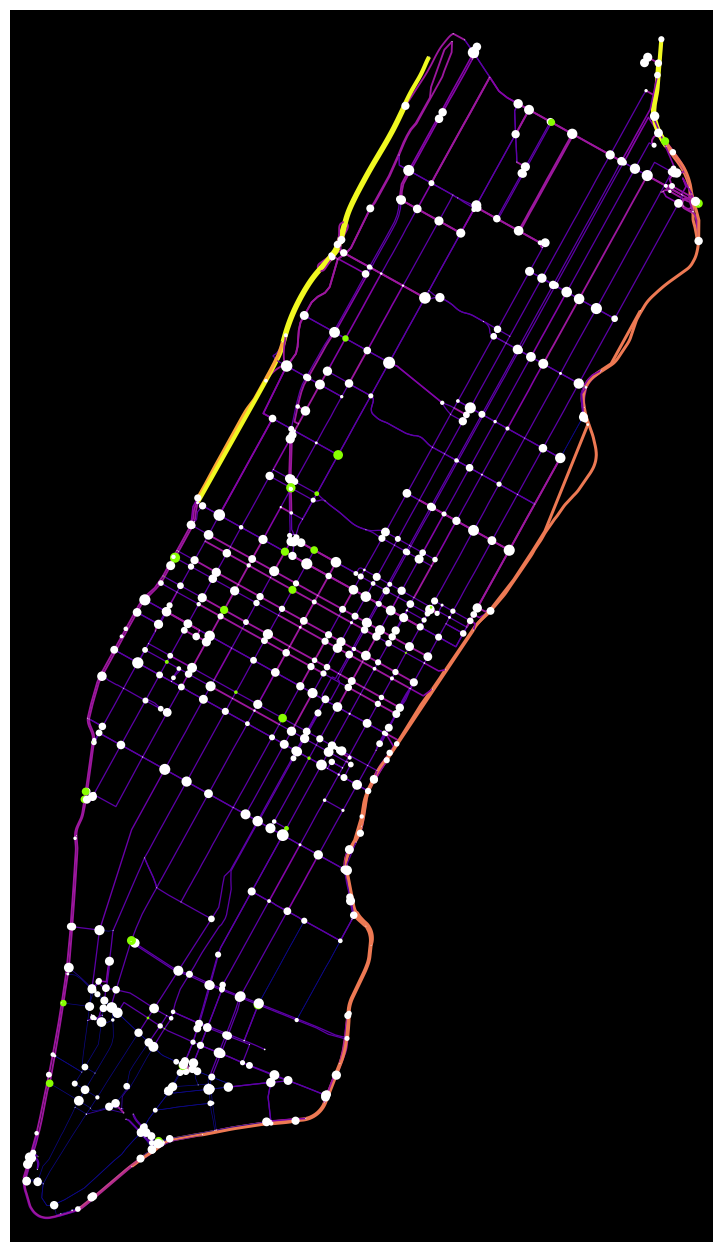

In [34]:
fig, ax = ox.plot_graph(
    G,
    edge_color=edge_colors,
    edge_linewidth=edge_widths,
    node_size=node_sizes,
    node_color=node_colors,
    figsize=(16, 16),
    show=False,
    bgcolor="black",
)